# Discrete Optimization — Swarm & ACO Visualization

This notebook visualizes how **biology-inspired** and **ACO** algorithms
tackle three classical discrete optimization problems:

| Problem | Objective | Solution Representation |
|---------|-----------|-------------------------|
| **TSP** | Minimise tour distance | Permutation of cities |
| **Knapsack** | Maximise value (within capacity) | Binary selection vector |
| **Graph Coloring** | Minimise edge conflicts | Integer color assignment |

We compare **ABC**, **CS**, **FA** (swarm), and
**Ant System**, **MMAS**, **ACS** (ant colony) on each problem,
plotting convergence curves, best-solution visualizations, and
pheromone heatmaps for the ACO variants.

In [ ]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), 'src'))
if not os.path.isdir(os.path.join(sys.path[0], 'AIP')):
    sys.path[0] = os.path.join(os.getcwd(), 'src')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

from AIP.problems.discrete import TSP, Knapsack, GraphColoring

from AIP.algorithm.natural.biology.abc import ArtificialBeeColony, ABCParameter
from AIP.algorithm.natural.biology.cs import CuckooSearch, CuckooSearchParameter
from AIP.algorithm.natural.biology.fa import FireflyAlgorithm, FireflyParameter

from AIP.algorithm.natural.biology.aco.ant_system import AntSystem, AntSystemParameter
from AIP.algorithm.natural.biology.aco.mmas import MMAS, MMASParameter
from AIP.algorithm.natural.biology.aco.acs import ACS, ACSParameter

print('Imports OK')

Imports OK


## Helper — Convergence Plot

In [2]:
def convergence_from_history(history_solutions, problem):
    """Compute running-best fitness from a list of best-solution snapshots."""
    best = float('inf')
    curve = []
    for sol in history_solutions:
        f = float(problem.eval(sol))
        best = min(best, f)
        curve.append(best)
    return curve


def plot_convergence(results, problem, title='Convergence'):
    """Plot convergence curves for multiple algorithms.

    Parameters
    ----------
    results : list of (name, history_solutions)
    problem : Problem instance (for re-evaluation)
    """
    fig, ax = plt.subplots(figsize=(9, 4))
    for name, hist in results:
        curve = convergence_from_history(hist, problem)
        ax.plot(curve, label=name, linewidth=2)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Best Fitness')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

---
# 1. Travelling Salesman Problem (TSP)

We use the **small** instance (10 cities) so tours can be drawn clearly.

In [3]:
tsp = TSP.create_small()
print(f'Cities: {tsp.n_cities}  —  {tsp.city_names}')
print(f'Distance matrix shape: {tsp.dist_matrix.shape}')

Cities: 10  —  ['C0', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9']
Distance matrix shape: (10, 10)


### 1.1 Run All Algorithms on TSP

In [5]:
N_ITER_TSP = 100
np.random.seed(42)

# --- Swarm algorithms ---
abc_tsp = ArtificialBeeColony(
    ABCParameter(n_bees=30, limit=50, iteration=N_ITER_TSP), tsp, stat=True)
abc_tsp.run()
print(f'ABC   best = {abc_tsp.best_fitness:.1f}')

cs_tsp = CuckooSearch(
    CuckooSearchParameter(n_nests=30, pa=0.25, alpha=0.01, beta=1.5,
                          iteration=N_ITER_TSP), tsp, stat=True)
cs_tsp.run()
print(f'CS    best = {cs_tsp.best_fitness:.1f}')

fa_tsp = FireflyAlgorithm(
    FireflyParameter(n_fireflies=30, alpha=0.5, beta0=1.0, gamma=1.0,
                     alpha_decay=0.97, cycle=N_ITER_TSP), tsp, stat=True)
fa_tsp.run()
print(f'FA    best = {fa_tsp.best_fitness:.1f}')

# --- ACO algorithms ---
as_tsp = AntSystem(
    AntSystemParameter(rho=0.5, m=20, q=100, alpha=1, beta=3, cycle=N_ITER_TSP), tsp)
as_tsp.run()
print(f'AS    best = {as_tsp.best_fitness:.1f}')

mmas_tsp = MMAS(
    MMASParameter(rho=0.02, m=20, alpha=1, beta=3, cycle=N_ITER_TSP), tsp)
mmas_tsp.run()
print(f'MMAS  best = {mmas_tsp.best_fitness:.1f}')

acs_tsp = ACS(
    ACSParameter(rho=0.1, xi=0.1, m=20, q0=0.9, alpha=1, beta=3,
                 cycle=N_ITER_TSP), tsp)
acs_tsp.run()
print(f'ACS   best = {acs_tsp.best_fitness:.1f}')

ABC   best = 264.6
CS    best = 264.6
FA    best = 279.3
AS    best = 264.6
MMAS  best = 264.6
ACS   best = 264.6


### 1.2 TSP Convergence Comparison

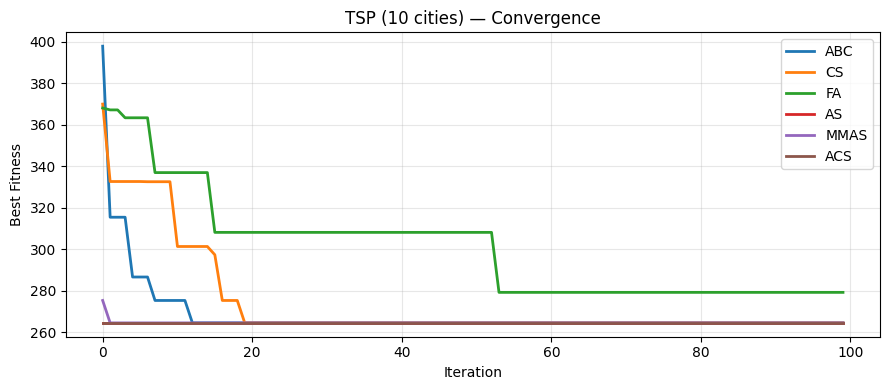

In [6]:
tsp_results = [
    ('ABC',  abc_tsp.history),
    ('CS',   cs_tsp.history),
    ('FA',   fa_tsp.history),
    ('AS',   as_tsp.history),
    ('MMAS', mmas_tsp.history),
    ('ACS',  acs_tsp.history),
]
plot_convergence(tsp_results, tsp, title='TSP (10 cities) — Convergence')

### 1.3 Best Tour Visualization

Draw the best tour found by each algorithm on a circular city layout.

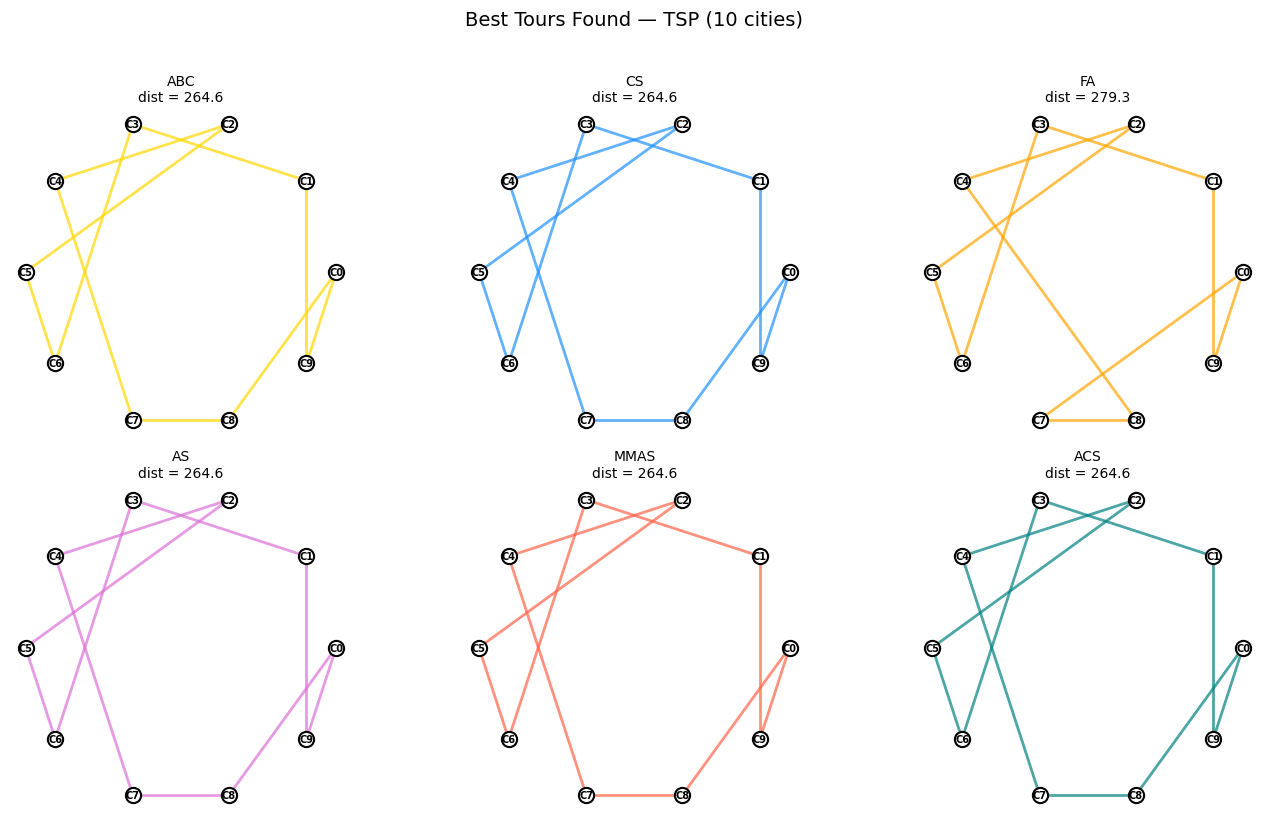

In [23]:
def draw_tsp_tour(ax, tour, tsp_problem, title='', color='steelblue'):
    """Draw a TSP tour on a circular layout."""
    n = tsp_problem.n_cities
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False)
    coords = np.column_stack([np.cos(angles), np.sin(angles)])

    # Draw edges of the tour
    perm = tour.astype(int)
    for k in range(n):
        i, j = perm[k], perm[(k + 1) % n]
        ax.plot([coords[i, 0], coords[j, 0]],
               [coords[i, 1], coords[j, 1]],
               color=color, linewidth=2, alpha=0.7)

    # Draw city nodes
    ax.scatter(coords[:, 0], coords[:, 1], s=120, c='white',
              edgecolors='black', zorder=5, linewidths=1.5)
    for idx in range(n):
        ax.text(coords[idx, 0], coords[idx, 1],
               tsp_problem.city_names[idx],
               ha='center', va='center', fontsize=7, fontweight='bold', zorder=6)

    dist = float(tsp_problem.eval(tour))
    ax.set_title(f'{title}\ndist = {dist:.1f}', fontsize=10)
    ax.set_aspect('equal')
    ax.axis('off')


algorithms_tsp = [
    ('ABC',  abc_tsp.best_solution,  'gold'),
    ('CS',   cs_tsp.best_solution,   'dodgerblue'),
    ('FA',   fa_tsp.best_solution,   'orange'),
    ('AS',   as_tsp.best_solution,   'orchid'),
    ('MMAS', mmas_tsp.best_solution, 'tomato'),
    ('ACS',  acs_tsp.best_solution,  'teal'),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for idx, (name, sol, c) in enumerate(algorithms_tsp):
    draw_tsp_tour(axes[idx], sol, tsp, title=name, color=c)
fig.suptitle('Best Tours Found — TSP (10 cities)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 1.4 ACO Pheromone Heatmaps

Visualize the final pheromone matrices of Ant System, MMAS, and ACS.
Brighter cells indicate edges that ants strongly prefer.

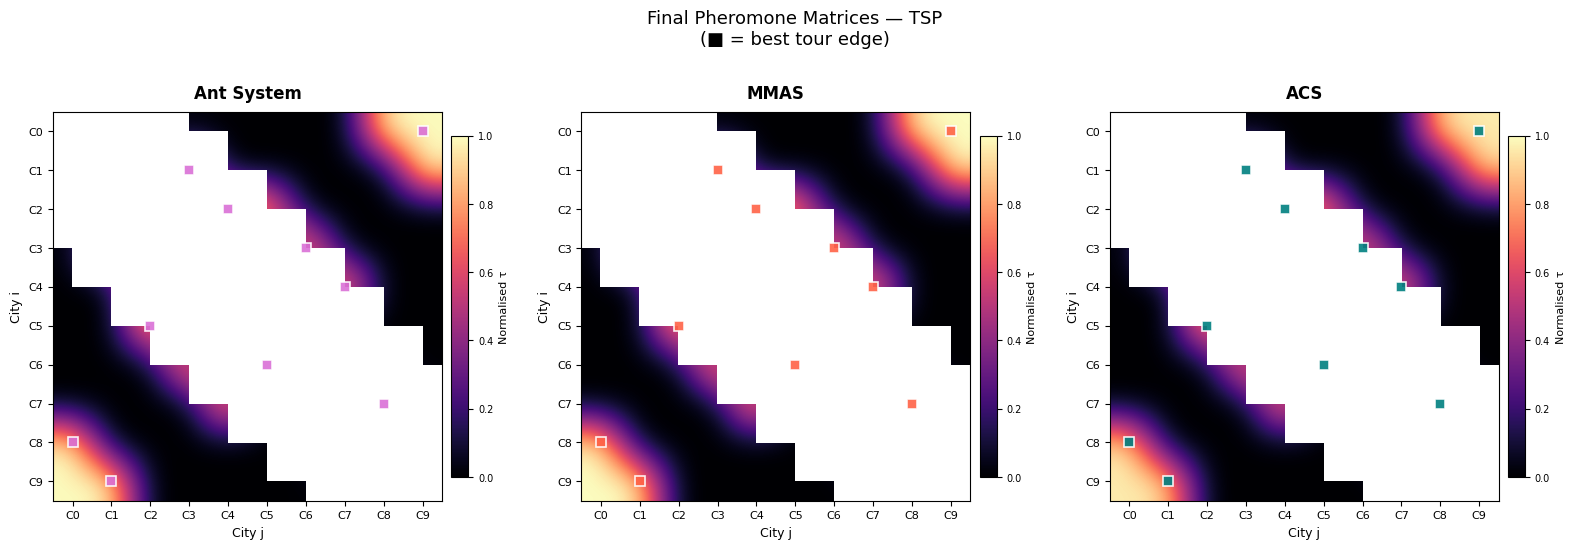

In [28]:
from matplotlib.colors import LogNorm

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

aco_data = [('Ant System', as_tsp, 'orchid'),
            ('MMAS', mmas_tsp, 'tomato'),
            ('ACS', acs_tsp, 'teal')]

for ax, (name, algo, color) in zip(axes, aco_data):
    tau = algo.tau.copy()
    np.fill_diagonal(tau, np.nan)  # mask diagonal (self-loops)

    # Normalise each matrix to [0, 1] for consistent comparison
    valid = tau[~np.isnan(tau)]
    tau_norm = (tau - np.nanmin(tau)) / (np.nanmax(tau) - np.nanmin(tau) + 1e-12)

    im = ax.imshow(tau_norm, cmap='magma', interpolation='bicubic',
                   vmin=0, vmax=1)
    ax.set_title(f'{name}', fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('City j', fontsize=9)
    ax.set_ylabel('City i', fontsize=9)
    ax.set_xticks(range(tsp.n_cities))
    ax.set_yticks(range(tsp.n_cities))
    ax.set_xticklabels(tsp.city_names, fontsize=8)
    ax.set_yticklabels(tsp.city_names, fontsize=8)

    # Overlay best tour edges as bright markers
    best = algo.best_solution.astype(int)
    for k in range(tsp.n_cities):
        i, j = best[k], best[(k + 1) % tsp.n_cities]
        ax.plot(j, i, 's', color=color, markersize=7, markeredgecolor='white',
                markeredgewidth=1.2, alpha=0.9)

    cb = plt.colorbar(im, ax=ax, shrink=0.82, pad=0.02)
    cb.set_label('Normalised τ', fontsize=8)
    cb.ax.tick_params(labelsize=7)

fig.suptitle('Final Pheromone Matrices — TSP\n(■ = best tour edge)',
             fontsize=13, y=1.04)
plt.tight_layout()
plt.show()

---
# 2. 0/1 Knapsack Problem

We use the **small** instance (20 items, capacity 270).

In [10]:
knapsack = Knapsack.create_small()
print(f'Items: {knapsack.n_items}   Capacity: {knapsack.capacity}')
print(f'Weights: {knapsack.weights}')
print(f'Values:  {knapsack.values}')

Items: 20   Capacity: 270.0
Weights: [ 5. 38. 33. 22. 22. 43.  5. 35. 10.  5. 26. 48. 37. 38. 36. 39. 26.  7.
 42. 23.]
Values:  [50. 37. 19. 92. 78. 64. 40. 82. 54. 44. 45. 23. 10. 55. 88.  7. 85. 82.
 28. 63.]


### 2.1 Run All Algorithms on Knapsack

In [12]:
N_ITER_KS = 150
np.random.seed(123)

# --- Swarm ---
abc_ks = ArtificialBeeColony(
    ABCParameter(n_bees=30, limit=50, iteration=N_ITER_KS), knapsack, stat=True)
abc_ks.run()
print(f'ABC   best = {abc_ks.best_fitness:.1f}')

cs_ks = CuckooSearch(
    CuckooSearchParameter(n_nests=30, pa=0.25, alpha=0.01, beta=1.5,
                          iteration=N_ITER_KS), knapsack, stat=True)
cs_ks.run()
print(f'CS    best = {cs_ks.best_fitness:.1f}')

fa_ks = FireflyAlgorithm(
    FireflyParameter(n_fireflies=30, alpha=0.5, beta0=1.0, gamma=1.0,
                     alpha_decay=0.97, cycle=N_ITER_KS), knapsack, stat=True)
fa_ks.run()
print(f'FA    best = {fa_ks.best_fitness:.1f}')

# --- ACO ---
as_ks = AntSystem(
    AntSystemParameter(rho=0.5, m=20, q=100, alpha=1, beta=2, cycle=N_ITER_KS), knapsack)
as_ks.run()
print(f'AS    best = {as_ks.best_fitness:.1f}')

mmas_ks = MMAS(
    MMASParameter(rho=0.02, m=20, alpha=1, beta=2, cycle=N_ITER_KS), knapsack)
mmas_ks.run()
print(f'MMAS  best = {mmas_ks.best_fitness:.1f}')

acs_ks = ACS(
    ACSParameter(rho=0.1, xi=0.1, m=20, q0=0.9, alpha=1, beta=2,
                 cycle=N_ITER_KS), knapsack)
acs_ks.run()
print(f'ACS   best = {acs_ks.best_fitness:.1f}')

ABC   best = -787.0
CS    best = -867.0
FA    best = -832.0
AS    best = 2378.0
MMAS  best = -858.0
ACS   best = 17284.0


### 2.2 Knapsack Convergence Comparison

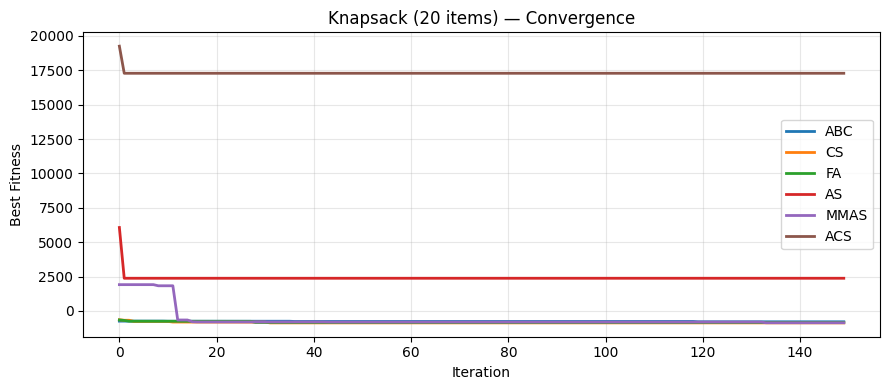

In [13]:
ks_results = [
    ('ABC',  abc_ks.history),
    ('CS',   cs_ks.history),
    ('FA',   fa_ks.history),
    ('AS',   as_ks.history),
    ('MMAS', mmas_ks.history),
    ('ACS',  acs_ks.history),
]
plot_convergence(ks_results, knapsack,
                 title='Knapsack (20 items) — Convergence')

### 2.3 Best Solution — Item Selection

A heatmap showing which items each algorithm selects in its best solution.
Rows are algorithms, columns are items. A filled cell means the item is packed.

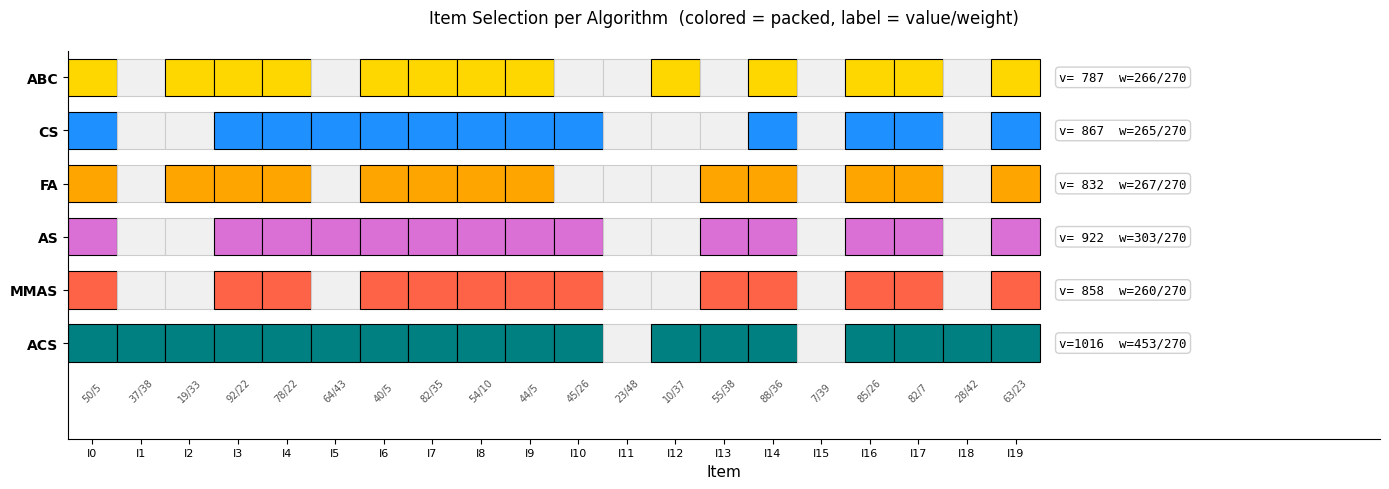

In [24]:
ks_algos = [
    ('ABC',  abc_ks, 'gold'),       ('CS',   cs_ks,   'dodgerblue'),
    ('FA',   fa_ks,  'orange'),     ('AS',   as_ks,   'orchid'),
    ('MMAS', mmas_ks,'tomato'),     ('ACS',  acs_ks,  'teal'),
]

n_algos = len(ks_algos)
n_items = knapsack.n_items

fig, ax = plt.subplots(figsize=(14, 5))

bar_h = 0.7  # bar height per row
for row, (name, algo, color) in enumerate(ks_algos):
    sel = algo.best_solution.astype(bool)
    for j in range(n_items):
        fc = color if sel[j] else '#f0f0f0'
        ec = 'black' if sel[j] else '#cccccc'
        ax.add_patch(plt.Rectangle(
            (j, row - bar_h / 2), 1, bar_h,
            facecolor=fc, edgecolor=ec, linewidth=0.8))

    # Summary annotation on the right — outside the grid
    total_v = float(np.dot(algo.best_solution, knapsack.values))
    total_w = float(np.dot(algo.best_solution, knapsack.weights))
    ax.text(n_items + 0.4, row,
            f'v={total_v:>4.0f}  w={total_w:>3.0f}/{knapsack.capacity:.0f}',
            va='center', ha='left', fontsize=9, fontfamily='monospace',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='#cccccc', alpha=0.9))

# Item value/weight labels on top
for j in range(n_items):
    ax.text(j + 0.5, n_algos + 0.15,
            f'{knapsack.values[j]:.0f}/{knapsack.weights[j]:.0f}',
            ha='center', va='bottom', fontsize=7, color='#555555', rotation=45)

ax.set_xlim(0, n_items + 7)
ax.set_ylim(-0.5, n_algos + 0.8)
ax.set_yticks(range(n_algos))
ax.set_yticklabels([name for name, _, _ in ks_algos], fontsize=10, fontweight='bold')
ax.set_xticks(np.arange(n_items) + 0.5)
ax.set_xticklabels([f'I{i}' for i in range(n_items)], fontsize=8)
ax.set_xlabel('Item', fontsize=11)
ax.set_title('Item Selection per Algorithm  (colored = packed, label = value/weight)',
             fontsize=12, pad=20)
ax.invert_yaxis()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

### 2.4 Value-Weight Scatter (Animated)

Each item plotted by weight (x) vs value (y). Flip through each algorithm
to see which items it packs (green) vs skips (gray).

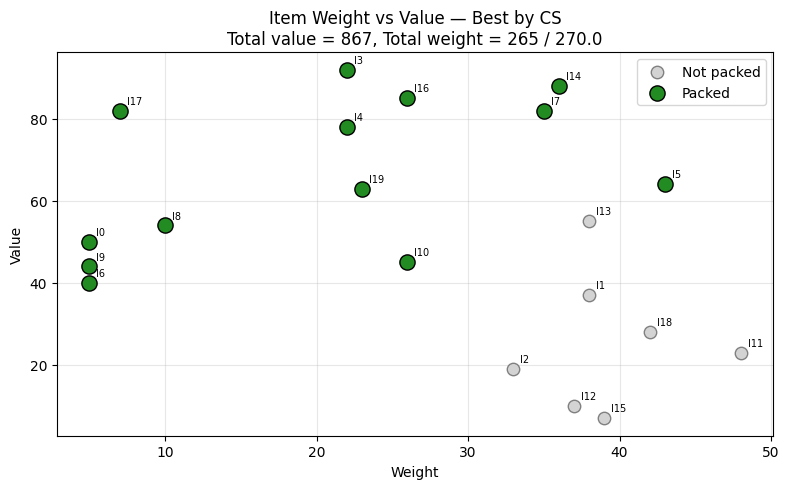

In [ ]:
def animate_knapsack_scatter(ks_algos, knapsack):
    """Animated scatter: flip through each algorithm's item selection."""
    fig, ax = plt.subplots(figsize=(8, 5))
    w, v = knapsack.weights, knapsack.values

    scat = ax.scatter(w, v, s=100, c='lightgray', edgecolors='gray', zorder=3)
    annotations = []
    for i in range(knapsack.n_items):
        ann = ax.annotate(f'I{i}', (w[i], v[i]),
                          textcoords='offset points', xytext=(5, 5), fontsize=7)
        annotations.append(ann)

    ax.set_xlabel('Weight', fontsize=11)
    ax.set_ylabel('Value', fontsize=11)
    ax.grid(True, alpha=0.3)
    title = ax.set_title('', fontsize=12)

    # Legend patches (static)
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='forestgreen',
               markeredgecolor='black', markersize=10, label='Packed'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgray',
               markeredgecolor='gray', markersize=10, label='Not packed'),
    ]
    ax.legend(handles=legend_elements, loc='upper left')
    plt.tight_layout()

    def update(frame):
        name, algo, color = ks_algos[frame]
        sel = algo.best_solution.astype(bool)
        colors = np.where(sel, color, '#d3d3d3')
        edge_colors = np.where(sel, 'black', '#aaaaaa')
        sizes = np.where(sel, 140, 80)
        scat.set_facecolors(colors)
        scat.set_edgecolors(edge_colors)
        scat.set_sizes(sizes)

        total_v = float(np.dot(algo.best_solution, knapsack.values))
        total_w = float(np.dot(algo.best_solution, knapsack.weights))
        title.set_text(
            f'{name}  —  value = {total_v:.0f},  '
            f'weight = {total_w:.0f} / {knapsack.capacity:.0f}')
        return scat, title

    anim = FuncAnimation(fig, update, frames=len(ks_algos),
                         interval=1500, repeat=True)
    plt.close(fig)
    return HTML(anim.to_jshtml())


animate_knapsack_scatter(ks_algos, knapsack)

### 2.5 ACO Pheromone Heatmaps — Knapsack

Pheromone matrix shape is `(n_items, 2)` — column 0 = "skip", column 1 = "pick".
Brighter cells show the ant colony's learned preference for each item.

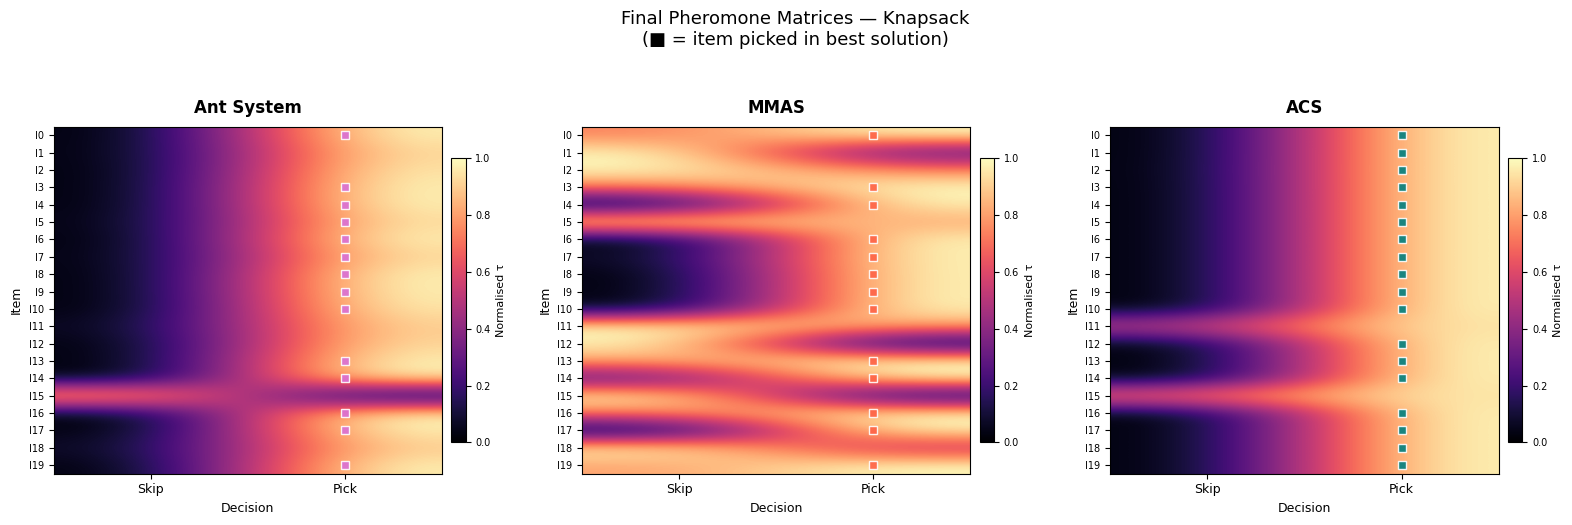

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

aco_ks_data = [('Ant System', as_ks, 'orchid'),
               ('MMAS', mmas_ks, 'tomato'),
               ('ACS', acs_ks, 'teal')]

item_labels = [f'I{i}' for i in range(knapsack.n_items)]

for ax, (name, algo, color) in zip(axes, aco_ks_data):
    tau = algo.tau.copy()
    # Normalise to [0, 1]
    tau_norm = (tau - tau.min()) / (tau.max() - tau.min() + 1e-12)

    im = ax.imshow(tau_norm, cmap='magma', interpolation='bicubic',
                   vmin=0, vmax=1, aspect='auto')
    ax.set_title(name, fontsize=12, fontweight='bold', pad=10)
    ax.set_ylabel('Item', fontsize=9)
    ax.set_xlabel('Decision', fontsize=9)
    ax.set_yticks(range(knapsack.n_items))
    ax.set_yticklabels(item_labels, fontsize=7)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Skip', 'Pick'], fontsize=9)

    # Overlay best solution markers on the "pick" column
    best_sol = algo.best_solution.astype(int)
    for i in range(knapsack.n_items):
        if best_sol[i] == 1:
            ax.plot(1, i, 's', color=color, markersize=6,
                    markeredgecolor='white', markeredgewidth=1.0, alpha=0.9)

    cb = plt.colorbar(im, ax=ax, shrink=0.82, pad=0.02)
    cb.set_label('Normalised τ', fontsize=8)
    cb.ax.tick_params(labelsize=7)

fig.suptitle('Final Pheromone Matrices — Knapsack\n(■ = item picked in best solution)',
             fontsize=13, y=1.04)
plt.tight_layout()
plt.show()

---
# 3. Graph Coloring

We use the **small** instance (Petersen graph — 10 vertices, 3 colors).

In [17]:
gc = GraphColoring.create_small()
print(f'Vertices: {gc.n_vertices}   Colors: {gc.n_colors}')
print(f'Edges: {gc.edges}')

Vertices: 10   Colors: 3
Edges: [(0, 1), (0, 4), (0, 5), (1, 2), (1, 6), (2, 3), (2, 7), (3, 4), (3, 8), (4, 9), (5, 7), (5, 8), (6, 8), (6, 9), (7, 9)]


### 3.1 Run All Algorithms on Graph Coloring

In [18]:
N_ITER_GC = 150
np.random.seed(7)

# --- Swarm ---
abc_gc = ArtificialBeeColony(
    ABCParameter(n_bees=30, limit=50, iteration=N_ITER_GC), gc, stat=True)
abc_gc.run()
print(f'ABC   conflicts = {abc_gc.best_fitness:.0f}')

cs_gc = CuckooSearch(
    CuckooSearchParameter(n_nests=30, pa=0.25, alpha=0.01, beta=1.5,
                          iteration=N_ITER_GC), gc, stat=True)
cs_gc.run()
print(f'CS    conflicts = {cs_gc.best_fitness:.0f}')

fa_gc = FireflyAlgorithm(
    FireflyParameter(n_fireflies=30, alpha=0.5, beta0=1.0, gamma=1.0,
                     alpha_decay=0.97, cycle=N_ITER_GC), gc, stat=True)
fa_gc.run()
print(f'FA    conflicts = {fa_gc.best_fitness:.0f}')

# --- ACO ---
as_gc = AntSystem(
    AntSystemParameter(rho=0.5, m=20, q=100, alpha=1, beta=2, cycle=N_ITER_GC), gc)
as_gc.run()
print(f'AS    conflicts = {as_gc.best_fitness:.0f}')

mmas_gc = MMAS(
    MMASParameter(rho=0.02, m=20, alpha=1, beta=2, cycle=N_ITER_GC), gc)
mmas_gc.run()
print(f'MMAS  conflicts = {mmas_gc.best_fitness:.0f}')

acs_gc = ACS(
    ACSParameter(rho=0.1, xi=0.1, m=20, q0=0.9, alpha=1, beta=2,
                 cycle=N_ITER_GC), gc)
acs_gc.run()
print(f'ACS   conflicts = {acs_gc.best_fitness:.0f}')

ABC   conflicts = 0
CS    conflicts = 0
FA    conflicts = 0
AS    conflicts = 0
MMAS  conflicts = 0
ACS   conflicts = 0


### 3.2 Graph Coloring Convergence

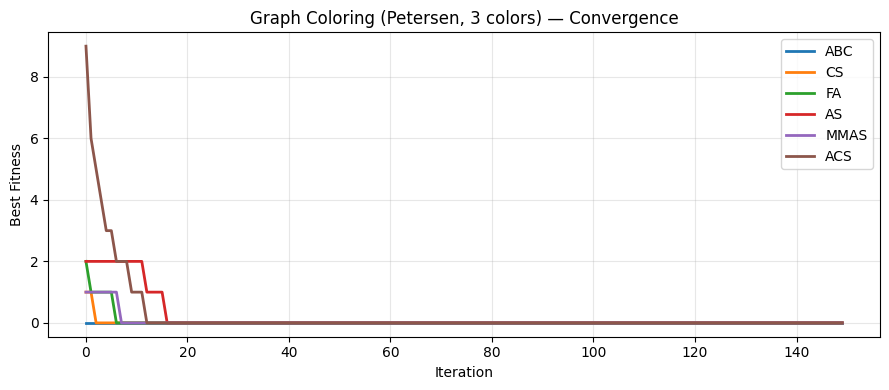

In [19]:
gc_results = [
    ('ABC',  abc_gc.history),
    ('CS',   cs_gc.history),
    ('FA',   fa_gc.history),
    ('AS',   as_gc.history),
    ('MMAS', mmas_gc.history),
    ('ACS',  acs_gc.history),
]
plot_convergence(gc_results, gc,
                 title='Graph Coloring (Petersen, 3 colors) — Convergence')

### 3.3 Best Coloring Visualization

Draw the graph with vertex colors from the best solution of each algorithm.
Conflicting edges (same color on both ends) are drawn in **red**.

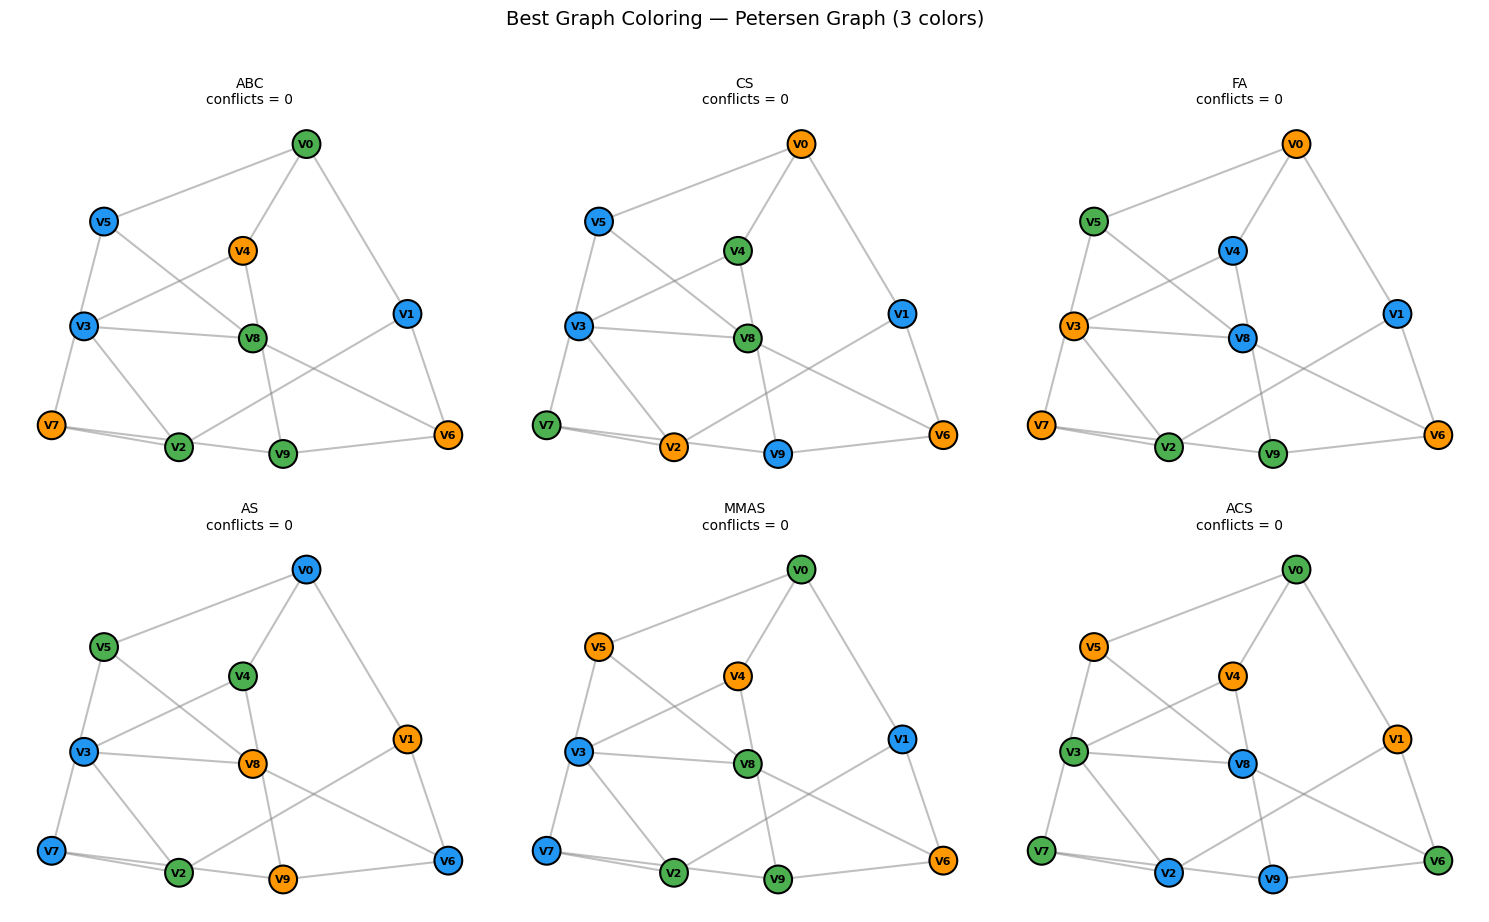

In [26]:
COLOR_PALETTE = ['#4CAF50', '#2196F3', '#FF9800', '#E91E63',
                 '#9C27B0', '#00BCD4', '#FFEB3B', '#795548']


def draw_graph_coloring(ax, solution, gc_problem, title=''):
    """Draw the graph with vertex colors and highlight conflicts."""
    G = nx.Graph()
    G.add_nodes_from(range(gc_problem.n_vertices))
    G.add_edges_from(gc_problem.edges)
    pos = nx.spring_layout(G, seed=42)

    sol = solution.astype(int)
    node_colors = [COLOR_PALETTE[sol[v] % len(COLOR_PALETTE)]
                   for v in range(gc_problem.n_vertices)]

    # Classify edges as conflict or OK
    conflict_edges = [(u, v) for u, v in gc_problem.edges if sol[u] == sol[v]]
    ok_edges = [(u, v) for u, v in gc_problem.edges if sol[u] != sol[v]]

    nx.draw_networkx_edges(G, pos, edgelist=ok_edges, ax=ax,
                          edge_color='gray', width=1.5, alpha=0.5)
    nx.draw_networkx_edges(G, pos, edgelist=conflict_edges, ax=ax,
                          edge_color='red', width=3, alpha=0.9, style='dashed')
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors,
                          node_size=400, edgecolors='black', linewidths=1.5)
    labels = {i: gc_problem.vertex_names[i] for i in range(gc_problem.n_vertices)}
    nx.draw_networkx_labels(G, pos, labels, ax=ax, font_size=8,
                           font_weight='bold')

    n_conflicts = int(gc_problem.eval(solution))
    ax.set_title(f'{title}\nconflicts = {n_conflicts}', fontsize=10)
    ax.axis('off')


gc_algos = [
    ('ABC',  abc_gc),  ('CS',  cs_gc),  ('FA',  fa_gc),
    ('AS',   as_gc),   ('MMAS', mmas_gc), ('ACS', acs_gc),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
for idx, (name, algo) in enumerate(gc_algos):
    draw_graph_coloring(axes[idx], algo.best_solution, gc, title=name)

fig.suptitle('Best Graph Coloring — Petersen Graph (3 colors)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 3.4 ACO Pheromone Heatmaps — Graph Coloring

Pheromone matrix shape is `(n_vertices, n_colors)` — each column is a color option.
Brighter cells show the ant colony's learned preference for assigning a specific
color to each vertex.

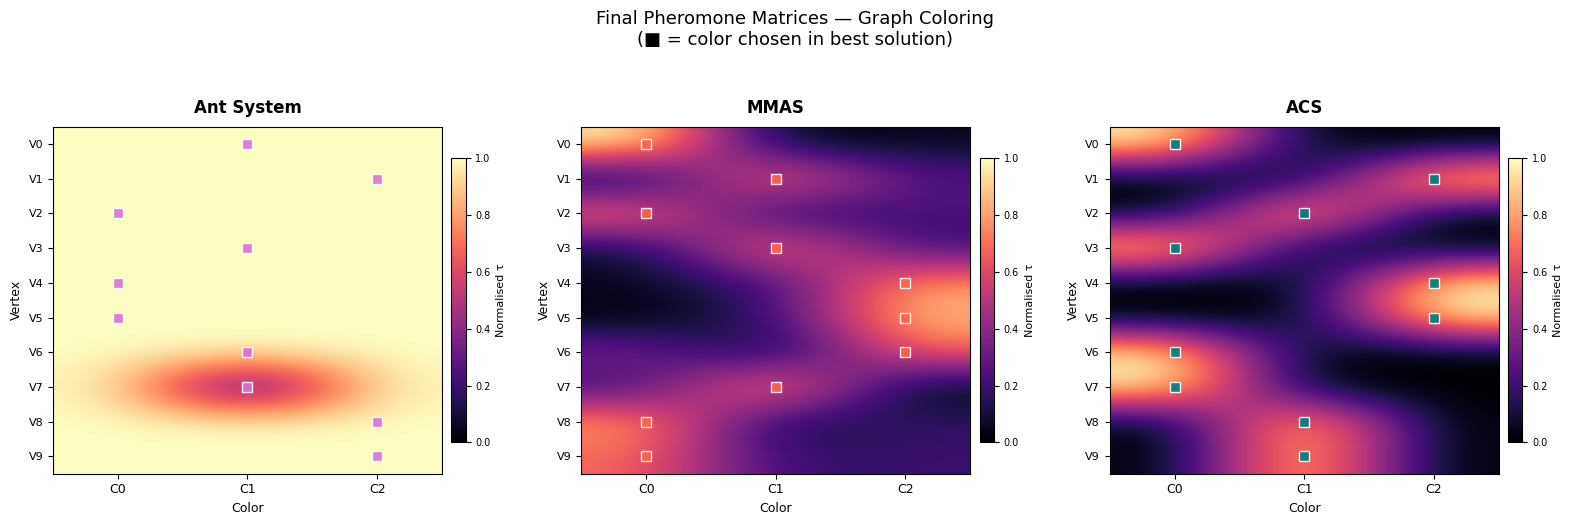

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

aco_gc_data = [('Ant System', as_gc, 'orchid'),
               ('MMAS', mmas_gc, 'tomato'),
               ('ACS', acs_gc, 'teal')]

color_labels = [f'C{c}' for c in range(gc.n_colors)]

for ax, (name, algo, color) in zip(axes, aco_gc_data):
    tau = algo.tau.copy()
    tau_norm = (tau - tau.min()) / (tau.max() - tau.min() + 1e-12)

    im = ax.imshow(tau_norm, cmap='magma', interpolation='bicubic',
                   vmin=0, vmax=1, aspect='auto')
    ax.set_title(name, fontsize=12, fontweight='bold', pad=10)
    ax.set_ylabel('Vertex', fontsize=9)
    ax.set_xlabel('Color', fontsize=9)
    ax.set_yticks(range(gc.n_vertices))
    ax.set_yticklabels(gc.vertex_names, fontsize=8)
    ax.set_xticks(range(gc.n_colors))
    ax.set_xticklabels(color_labels, fontsize=9)

    # Overlay best solution — mark the chosen color for each vertex
    best_sol = algo.best_solution.astype(int)
    for v in range(gc.n_vertices):
        ax.plot(best_sol[v], v, 's', color=color, markersize=7,
                markeredgecolor='white', markeredgewidth=1.0, alpha=0.9)

    cb = plt.colorbar(im, ax=ax, shrink=0.82, pad=0.02)
    cb.set_label('Normalised τ', fontsize=8)
    cb.ax.tick_params(labelsize=7)

fig.suptitle('Final Pheromone Matrices — Graph Coloring\n(■ = color chosen in best solution)',
             fontsize=13, y=1.04)
plt.tight_layout()
plt.show()

---
# 4. Summary — Final Fitness Comparison (Bar Chart)

Side-by-side bar chart of the best fitness achieved by each algorithm
across all three problems.

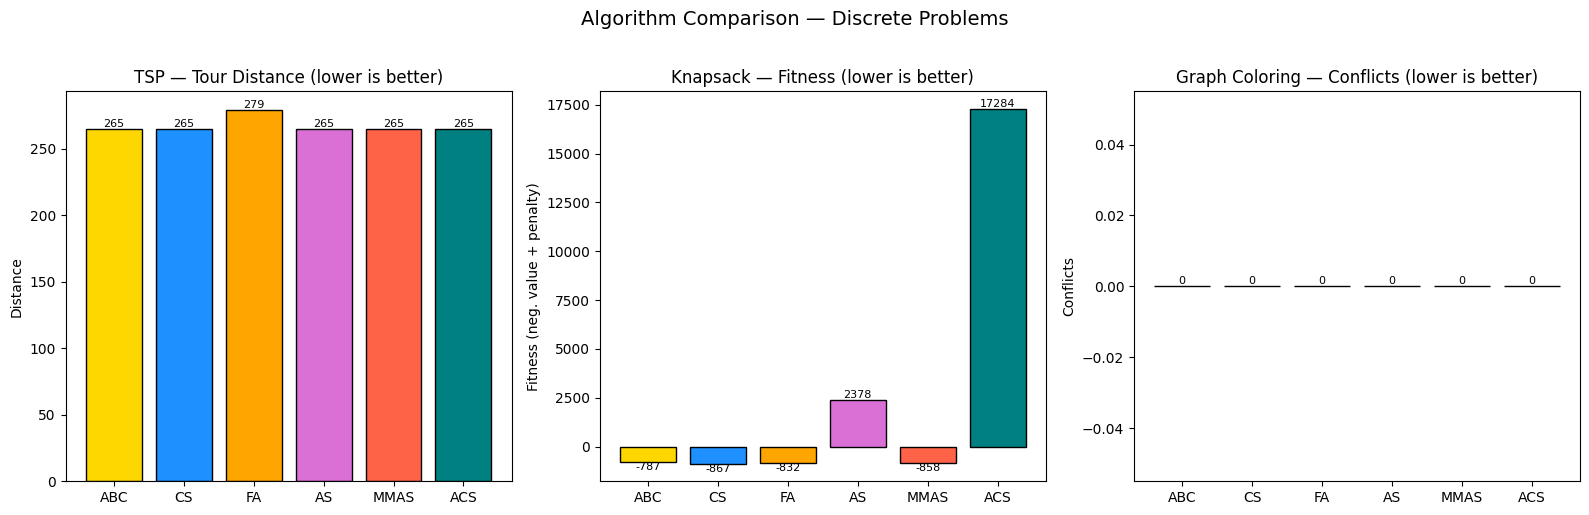

In [27]:
algo_names = ['ABC', 'CS', 'FA', 'AS', 'MMAS', 'ACS']

tsp_fits = [abc_tsp.best_fitness, cs_tsp.best_fitness, fa_tsp.best_fitness,
            as_tsp.best_fitness, mmas_tsp.best_fitness,
            acs_tsp.best_fitness]

ks_fits = [abc_ks.best_fitness, cs_ks.best_fitness, fa_ks.best_fitness,
           as_ks.best_fitness, mmas_ks.best_fitness,
           acs_ks.best_fitness]

gc_fits = [abc_gc.best_fitness, cs_gc.best_fitness, fa_gc.best_fitness,
           as_gc.best_fitness, mmas_gc.best_fitness,
           acs_gc.best_fitness]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors = ['gold', 'dodgerblue', 'orange', 'orchid', 'tomato', 'teal']

axes[0].bar(algo_names, tsp_fits, color=colors, edgecolor='black')
axes[0].set_title('TSP — Tour Distance (lower is better)')
axes[0].set_ylabel('Distance')
for i, v in enumerate(tsp_fits):
    axes[0].text(i, v, f'{v:.0f}', ha='center', va='bottom', fontsize=8)

axes[1].bar(algo_names, ks_fits, color=colors, edgecolor='black')
axes[1].set_title('Knapsack — Fitness (lower is better)')
axes[1].set_ylabel('Fitness (neg. value + penalty)')
for i, v in enumerate(ks_fits):
    axes[1].text(i, v, f'{v:.0f}', ha='center',
               va='bottom' if v >= 0 else 'top', fontsize=8)

axes[2].bar(algo_names, gc_fits, color=colors, edgecolor='black')
axes[2].set_title('Graph Coloring — Conflicts (lower is better)')
axes[2].set_ylabel('Conflicts')
for i, v in enumerate(gc_fits):
    axes[2].text(i, v, f'{v:.0f}', ha='center', va='bottom', fontsize=8)

fig.suptitle('Algorithm Comparison — Discrete Problems', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()